# 构建数据集

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

## 导入数据

In [ ]:
# df_merged: raw data
# df_merged_fe: data with ratio features
# df_merged_fe1: data with ratio and mean features

file_name = 'df_merged.csv'
df_merged = pd.read_csv(file_name)
print('drop return extreme values:', before_shape, '->', df_merged.shape)
df_merged.head()

## 数据概况

In [6]:
df_merged.shape

(216057, 10)

In [9]:
# df_merged.info()

In [8]:
pd.set_option('display.float_format', '{:.5}'.format)
display(df_merged.drop(['code', 'date'], axis=1).describe())
pd.reset_option('display.float_format')

,open,close,high,low,volumn,vwap,return,turn
count,2.1606e+05,2.1606e+05,2.1606e+05,2.1606e+05,2.1606e+05,2.1606e+05,2.1606e+05,2.1606e+05
mean,8.4127,8.4225,8.5675,8.2735,3.4086e+07,10.627,0.029375,1.3506
std,7.9666,7.9762,8.1291,7.8233,8.3733e+07,8.8507,2.4674,1.9516
min,0.17,0.16,0.18,0.16,5700.0,0.16707,-66.667,0.0004
25%,3.7396,3.7443,3.7965,3.6882,4.7989e+06,5.1944,-1.1183,0.3618
50%,6.2486,6.2545,6.356,6.1478,1.1873e+07,8.1288,0.0,0.74146
75%,10.15,10.164,10.341,9.9767,3.2465e+07,12.962,1.092,1.5437
max,83.914,83.742,85.082,83.742,4.1145e+09,88.147,11.765,74.387


## 收益率

In [9]:
pd.set_option('display.float_format', '{:.5}'.format)
display(df_merged['return'].describe())
pd.reset_option('display.float_format')

count   2.1606e+05
mean      0.029375
std         2.4674
min        -66.667
25%        -1.1183
50%            0.0
75%          1.092
max         11.765
Name: return, dtype: float64

C:\Users\wjyyy\AppData\Local\Temp\ipykernel_20476\3651409728.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_merged['return'], fit=norm)


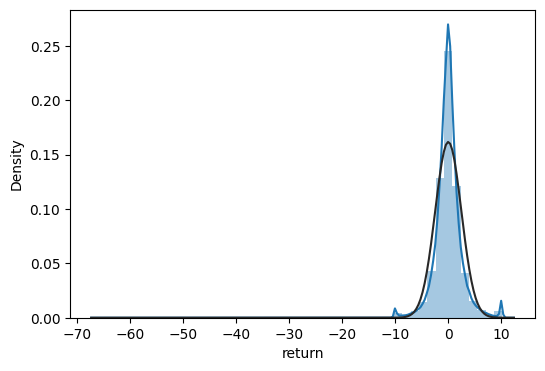

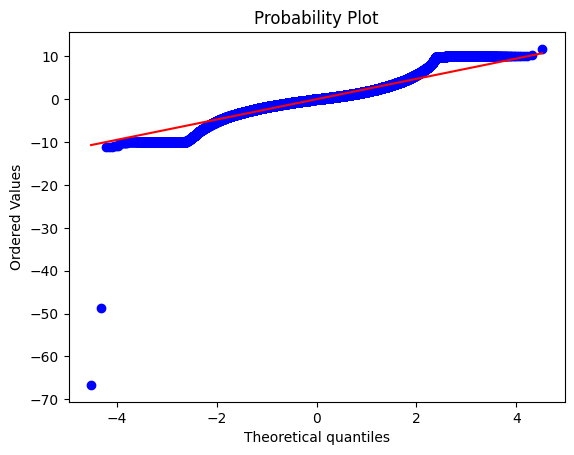

In [10]:
from scipy import stats
from scipy.stats import norm

plt.figure(figsize=(6,4))
sns.distplot(df_merged['return'], fit=norm)
plt.plot()
fig = plt.figure()
res = stats.probplot(df_merged['return'], plot=plt)

In [13]:
print("Skewness: %f" % df_merged['return'].skew())
print("Kurtosis: %f" % df_merged['return'].kurt())

Skewness: 0.559080
Kurtosis: 3.881802


## 标准化特征

In [13]:
# 创建标签列，保留不变
df_merged['target'] = df_merged['return']

# 对每个特征分别进行归一化
for feature in df_merged.columns[2:-1]:
    df_merged[feature] = (df_merged[feature] - df_merged[feature].mean()) / df_merged[feature].std()

df_merged.head()

,code,date,open,close,high,low,volumn,vwap,return,turn,target
0,600000.SH,2011-02-01,-0.590866,-0.590295,-0.596668,-0.586869,0.092417,0.236679,0.115541,-0.505370,0.314465
1,600000.SH,2011-02-09,-0.591597,-0.595039,-0.594520,-0.589101,0.194170,0.236446,-0.424807,-0.467339,-1.018809
2,600000.SH,2011-02-10,-0.595251,-0.589930,-0.595952,-0.589845,0.159021,0.232051,0.437335,-0.480476,1.108472
3,600000.SH,2011-02-11,-0.590135,-0.590659,-0.596310,-0.587613,0.626258,0.233014,-0.075379,-0.305841,-0.156617
4,600000.SH,2011-02-14,-0.590866,-0.576427,-0.581271,-0.584264,1.450289,0.270680,1.227771,0.002150,3.058824


## 构建特征图&标签

每隔10个交易日采样（防止过于频繁的采样导致数据相似度太高）

In [ ]:
X, Y, Y_dates, empty = [], [], [], []


for code in tqdm(df_merged['code'].unique()):
    
    x, y, dates = [], [], []
    
    # 每个个股单独采样
    df = df_merged[df_merged['code']==code]
    
    i = 0
    while i + 40 < len(df):
        
        # 标签对应的日期
        date = df.iloc[i+40]['date']
        dates.append(date)
        
        # 特征：30天的历史窗口，构建 ”数据图片“
        window = df.iloc[i:i+30, 1:-1]
        window.set_index('date', inplace=True)
        window = window.transpose()          # 转置为 (特征数, 天数) = (9, 30)
        x.append(np.array(window))
        
        # 标签：第i+40天的收益率
        y.append(df.iloc[i+40]['target'])
        
        # 每间隔10个交易日采样一次
        i += 10
    
    # 如果该个股的数据不够，跳过
    if not x or not y:
        empty.append(code)
        continue
    
    # 将该个股的所有的 样本-标签 组合加入到数据集中
    x = np.stack(x)         # 将list转为numpy数组，形状: (该股票样本数, 9, 30)
    y = np.stack(y)
    y_dates = np.stack(dates)
    X.append(x)                 # 加入该股票所有日期的特征
    Y.append(y)                 # 加入该股票所有日期的标签
    Y_dates.append(y_dates)     # 加入该股票所有的标签日期


# 根据标签日期对数据集进行排序
Y_dates = np.concatenate(Y_dates, axis=0)
order = np.argsort(Y_dates)     # 获取按日期升序排列的索引
X = np.concatenate(X, axis=0)[order]
Y = np.concatenate(Y, axis=0)[order]
Y_dates = Y_dates[order]

# 相同日期的数据会连续排列，同一天内部的股票顺序没有明确保证
print('Shape of X: ', X.shape)                  # (N, 9, 30)
print('Shape of Y: ', Y.shape)                  # (N, )
print('Stocks with not enough data: ', empty)   # (N, )

100%|██████████| 83/83 [00:25<00:00,  3.21it/s]

Shape of X:  (21313, 8, 30)
Shape of Y:  (21313,)
Stocks with not enough data:  ['600091.SH']


## 标签转换

In [45]:
# 构建超额收益标签：判断个股在对应日期的收益率是否超过当天的市场均值，超过则标签为1，否则为0

memo = {}
Y_cls = []

for i in tqdm(range(len(Y))):
    
    # 目标日期
    date = Y_dates[i]
    
    # 获取当天的市场收益率均值
    if date in memo:
        avg = memo[date]
    else:
        avg = df_merged[df_merged['date']==date]['target'].mean()
        memo[date] = avg
    
    # 判断标签取值
    if Y[i] > avg:
        Y_cls.append(1)
    else:
        Y_cls.append(0)

100%|██████████████████████████████████| 105637/105637 [01:59<00:00, 884.97it/s]


In [46]:
Y_cls = np.array(Y_cls)
Y_cls.shape

(105637,)

In [47]:
Y_cls[:10]

array([0, 1, 1, 0, 1, 1, 1, 0, 1, 1])

## 标准化收益率

In [11]:
np.mean(Y), np.std(Y)

(0.08304253433929398, 3.092383135172094)

In [13]:
Y[:5]

array([-1.5487,  0.    ,  3.8362,  0.4219,  0.0717])

In [12]:
# 标准化收益率标签
Y_norm = (Y - np.mean(Y)) / np.std(Y)

np.mean(Y_norm), np.std(Y_norm)

(9.685825416232422e-18, 1.0)

In [14]:
Y_norm[:5]

array([-0.52766506, -0.0268539 ,  1.21367803,  0.1095781 , -0.00366789])

## 储存数据集

In [49]:
# 储存数据集到本地
np.save('X_fe.npy', X)
np.save('Y_fe_cls.npy', Y_cls)
np.save('Y_fe_norm.npy', Y_norm)
np.save('Y_dates.npy', Y_dates)